<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 169 &middot; Capstone 10 &middot; Proportion Tests</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Did the Campaign Beat Its Target?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">Two questions about rates, from one dataset. Did campaign A clear its target? And does campaign B convert better than A? One of those questions gets a clear answer and the other does not, which is the point.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, confint_proportions_2indep
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"
TARGET = 0.07

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-email-signup-rates.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="visitors")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="visitors")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 3002 rows


,visitor_id,campaign,signed_up
0,V2571,A,0.0
1,V3674,B,0.0
2,V4858,B,0.0
3,V2331,A,1.0
4,V3295,A,0.0


## Step 1 &middot; Two goals, two hypotheses
Two email campaigns ran at the same time; every visitor saw exactly one. Marketing has two separate questions, and they need two separate tests.

**Question 1 (one-sample).** The company's signup target is **7%**. Did campaign A clear it?
- H&#8320;: campaign A's true signup rate = 0.07&nbsp;&nbsp;vs&nbsp;&nbsp;H&#8321;: it differs. Two-sided, &#945; = 0.05.

**Question 2 (two-sample).** Does campaign B convert better than campaign A?
- H&#8320;: the two campaigns have the same true rate&nbsp;&nbsp;vs&nbsp;&nbsp;H&#8321;: they differ. Two-sided, &#945; = 0.05.

The first compares one rate against a fixed number; the second compares two rates against each other. They are different tests, and in this dataset they reach different verdicts.

## Step 2 &middot; Know the data type
The outcome, `signed_up`, is **binary**: 1 or 0 for each visitor. Averaging a column of 0s and 1s gives a **proportion**, which is why the methods here look like the t-test family but use the binomial standard error instead.

In [2]:
print(raw.dtypes)
print("\nsigned_up values:", sorted(raw.signed_up.dropna().unique()))
print("campaigns:", sorted(raw.campaign.unique()))
print("\na binary outcome averaged over visitors IS a proportion -> proportion tests")

visitor_id        str
campaign          str
signed_up     float64
dtype: object

signed_up values: [np.float64(0.0), np.float64(1.0)]
campaigns: ['A', 'B']

a binary outcome averaged over visitors IS a proportion -> proportion tests


## Step 3 &middot; Prepare and clean
Only two fixes are needed: drop **duplicate rows** and drop visitors whose outcome was never recorded. A missing outcome cannot be counted as a non-signup, because we do not know that it was one.

In [3]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["signed_up"]).copy()
df["signed_up"] = df.signed_up.astype(int)
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  outcome recorded {len(df)} (-{a_dup-len(df)})")
A = df[df.campaign=="A"].signed_up; B = df[df.campaign=="B"].signed_up
xA, nA = int(A.sum()), len(A); xB, nB = int(B.sum()), len(B)
pA, pB = xA/nA, xB/nB
print(f"\ncampaign A: {xA:4d} signups / {nA:5d} visitors = {pA:.4f}  ({pA:.2%})")
print(f"campaign B: {xB:4d} signups / {nB:5d} visitors = {pB:.4f}  ({pB:.2%})")

start 3002  ->  dedup 3000 (-2)  ->  outcome recorded 2998 (-2)

campaign A:  113 signups /  1499 visitors = 0.0754  (7.54%)
campaign B:  171 signups /  1499 visitors = 0.1141  (11.41%)


**What the raw rates say.** Campaign A converts at about 7.5%, just above the 7% target. Campaign B converts at about 11.4%, clearly higher than A. Whether either of those gaps is real is what the two tests decide, and note in advance how different the two situations look: A is barely above its target, while B is half again as high as A.

## Step 4 &middot; Check the assumption
Both proportion tests rely on a normal approximation to the binomial, which needs enough events **and** enough non-events. The usual rule is at least **10 successes and 10 failures** in each group.

In [4]:
for name, x, n in [("A", xA, nA), ("B", xB, nB)]:
    print(f"campaign {name}: successes {x}, failures {n-x}   -> {'OK' if min(x, n-x)>=10 else 'TOO FEW: use an exact test'}")
print(f"\nagainst the target: n*p = {nA*TARGET:.1f}, n*(1-p) = {nA*(1-TARGET):.1f}  -> OK")
print("\nwith thousands of visitors the approximation is comfortable;")
print("for small samples the exact binomial test is the fallback, and we run it below as a check.")

campaign A: successes 113, failures 1386   -> OK
campaign B: successes 171, failures 1328   -> OK

against the target: n*p = 104.9, n*(1-p) = 1394.1  -> OK

with thousands of visitors the approximation is comfortable;
for small samples the exact binomial test is the fallback, and we run it below as a check.


## Step 5 &middot; Question 1, campaign A against the 7% target

In [5]:
z1, p1 = proportions_ztest(xA, nA, value=TARGET, prop_var=TARGET)
lo1, hi1 = proportion_confint(xA, nA, alpha=0.05, method="wilson")
exact = stats.binomtest(xA, nA, TARGET, alternative="two-sided")
print(f"observed rate      : {pA:.4f}  ({pA:.2%})")
print(f"target             : {TARGET:.4f}  ({TARGET:.0%})")
print(f"difference         : {pA-TARGET:+.4f}  ({(pA-TARGET)*100:+.2f} percentage points)")
print(f"\none-sample z-test  : z = {z1:.3f},  p = {p1:.4f}")
print(f"95% Wilson CI      : [{lo1:.4f}, {hi1:.4f}]  =  [{lo1:.2%}, {hi1:.2%}]")
print(f"exact binomial     : p = {exact.pvalue:.4f}   (agrees)")
print("\nverdict:", "reject H0" if p1<0.05 else "DO NOT reject H0: not distinguishable from target")

observed rate      : 0.0754  (7.54%)
target             : 0.0700  (7%)
difference         : +0.0054  (+0.54 percentage points)

one-sample z-test  : z = 0.817,  p = 0.4140
95% Wilson CI      : [0.0631, 0.0899]  =  [6.31%, 8.99%]
exact binomial     : p = 0.4177   (agrees)

verdict: DO NOT reject H0: not distinguishable from target


**Reading the first result.** Campaign A came in at 7.54% against a 7% target, so it is **numerically above** the target. But the test cannot distinguish that from ordinary sampling noise (p = 0.41), and the confidence interval, roughly **6.3% to 9.0%, comfortably contains 7%**. The honest statement is not "A beat its target" and not "A missed its target", but **"A is running at or about its target, and this sample cannot tell us which side of it"**. The exact binomial test agrees, so the conclusion is not an artifact of the approximation.

## Step 6 &middot; Question 2, campaign B against campaign A

In [6]:
z2, p2 = proportions_ztest([xB, xA], [nB, nA])
d_lo, d_hi = confint_proportions_2indep(xB, nB, xA, nA, method="wald")
diff = pB - pA
rel = pB/pA - 1
print(f"campaign B rate    : {pB:.4f}  ({pB:.2%})")
print(f"campaign A rate    : {pA:.4f}  ({pA:.2%})")
print(f"\ntwo-sample z-test  : z = {z2:.3f},  p = {p2:.2e}")
print(f"absolute difference: {diff:+.4f}  ({diff*100:+.2f} percentage points)")
print(f"95% CI for the difference: [{d_lo:.4f}, {d_hi:.4f}]  =  [{d_lo*100:+.2f}, {d_hi*100:+.2f}] pp")
print(f"relative lift      : {rel:+.1%}")

campaign B rate    : 0.1141  (11.41%)
campaign A rate    : 0.0754  (7.54%)

two-sample z-test  : z = 3.617,  p = 2.98e-04
absolute difference: +0.0387  (+3.87 percentage points)
95% CI for the difference: [0.0178, 0.0596]  =  [+1.78, +5.96] pp
relative lift      : +51.3%


**Reading the second result.** Campaign B beats A decisively (p is about 0.0003), and the interval for the gap, roughly **1.8 to 6.0 percentage points**, stays well clear of zero. So the same dataset that could not distinguish A from its target has no trouble distinguishing B from A. The reason is the size of the gap: 0.54 points versus 3.87 points.

## Step 7 &middot; The two ways to report the same win
The gap between A and B can be stated as **3.87 percentage points** or as a **51% relative lift**, and both are correct. They are not interchangeable.

In [7]:
print(f"absolute: {diff*100:+.2f} percentage points  (7.54% -> 11.41%)")
print(f"relative: {rel:+.1%} lift            (11.41 / 7.54 - 1)")
print()
extra_per_10k = diff*10000
print(f"on 10,000 visitors, campaign B produces about {extra_per_10k:.0f} more signups than A")

absolute: +3.87 percentage points  (7.54% -> 11.41%)
relative: +51.3% lift            (11.41 / 7.54 - 1)

on 10,000 visitors, campaign B produces about 387 more signups than A


**Why the framing matters.** "A 51% lift" sounds transformative; "3.9 more signups per hundred visitors" sounds modest. Both describe the identical result. Relative figures exaggerate when the base rate is small, which is why a good readout gives the **absolute difference with its interval** and then translates it into a concrete quantity, here about **387 extra signups per 10,000 visitors**. This is the reporting discipline from [Chapter 157](../../communicating-insights-and-storytelling-with-data.html), applied to a real test.

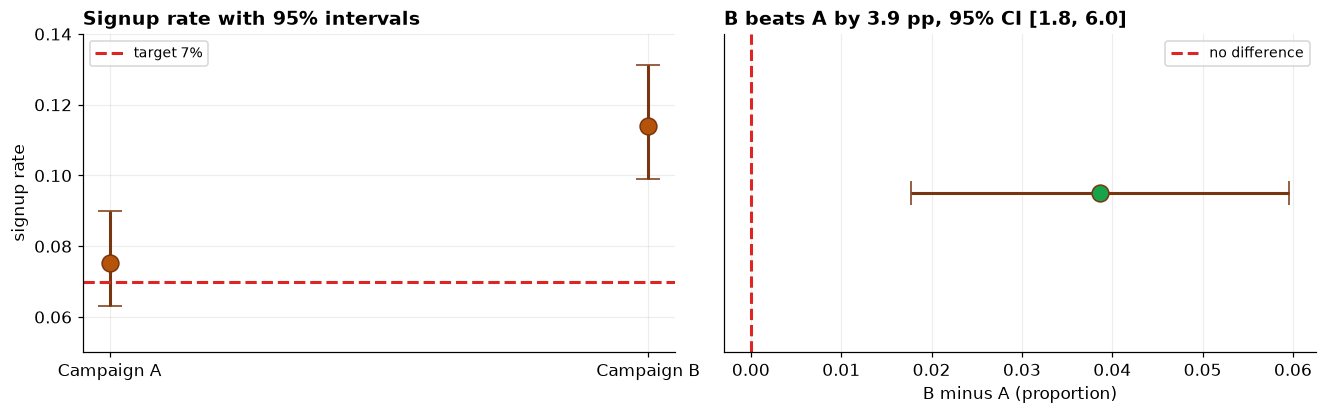

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.2, 3.9))
# (a) rates with CIs vs target
names = ["Campaign A", "Campaign B"]
rates = [pA, pB]
cis = [proportion_confint(xA, nA, method="wilson"), proportion_confint(xB, nB, method="wilson")]
err = [[r-c[0] for r, c in zip(rates, cis)], [c[1]-r for r, c in zip(rates, cis)]]
ax[0].errorbar(names, rates, yerr=err, fmt="o", markersize=11, capsize=8, lw=2,
               color=DARK, markerfacecolor=GOLD, markeredgecolor=DARK, ls="none")
ax[0].axhline(TARGET, color=RD, lw=2, ls="--", label=f"target {TARGET:.0%}")
ax[0].set_ylabel("signup rate"); ax[0].set_ylim(0.05, 0.14)
ax[0].set_title("Signup rate with 95% intervals"); ax[0].legend(fontsize=9)
# (b) difference with CI
ax[1].errorbar([diff], [0], xerr=[[diff-d_lo],[d_hi-diff]], fmt="o", markersize=11,
               capsize=8, lw=2, color=DARK, markerfacecolor=GR, markeredgecolor=DARK, ls="none")
ax[1].axvline(0, color=RD, lw=2, ls="--", label="no difference")
ax[1].set_yticks([]); ax[1].set_xlabel("B minus A (proportion)")
ax[1].set_title(f"B beats A by {diff*100:.1f} pp, 95% CI [{d_lo*100:.1f}, {d_hi*100:.1f}]")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**The two questions in one picture.** On the left, campaign A's interval **straddles the target line** while campaign B's sits well above it. On the right, the difference between the campaigns is clearly separated from zero. The left panel is why we could not call question 1, and the right panel is why question 2 was easy.

## Step 8 &middot; What could this study have detected?
Campaign A came back inconclusive against the 7 percent target: p = 0.41, and the interval covers the target. That is not the same as showing A hits the target. Before anyone treats it as reassurance, the honest follow-up is to ask what gap this sample was capable of finding.

In [9]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# 1. Precision: how wide is the interval we actually got?
print(f"campaign A: {xA}/{nA} = {pA*100:.2f}%   95% CI [{lo1*100:.2f}%, {hi1*100:.2f}%]")
print(f"margin of error: +/- {(hi1-lo1)/2*100:.2f} percentage points")
print(f"the target of {TARGET*100:.0f}% sits inside that interval, so it is not ruled out\n")

# 2. Minimum detectable effect at 80% power for the one-sample comparison.
power = NormalIndPower()
for pwr in (0.80, 0.90):
    for cand in np.arange(0.0001, 0.06, 0.0001):
        es = proportion_effectsize(TARGET + cand, TARGET)
        if power.solve_power(effect_size=es, nobs1=nA, ratio=0, alpha=0.05, alternative="two-sided") >= pwr:
            print(f"with n = {nA}, the smallest gap detectable at {pwr:.0%} power is "
                  f"{cand*100:.2f} pp (i.e. a true rate of {(TARGET+cand)*100:.2f}%)")
            break

# 3. What would it take to resolve the gap we actually observed?
obs_gap = abs(pA - TARGET)
es_obs = proportion_effectsize(pA, TARGET)
n_need = power.solve_power(effect_size=es_obs, power=0.80, alpha=0.05, ratio=0, alternative="two-sided")
print(f"\nthe observed gap is {obs_gap*100:.2f} pp; confirming a gap that small at 80% power")
print(f"would need about {int(np.ceil(n_need)):,} visitors, roughly {n_need/nA:.0f}x this sample")

campaign A: 113/1499 = 7.54%   95% CI [6.31%, 8.99%]
margin of error: +/- 1.34 percentage points
the target of 7% sits inside that interval, so it is not ruled out

with n = 1499, the smallest gap detectable at 80% power is 1.96 pp (i.e. a true rate of 8.96%)
with n = 1499, the smallest gap detectable at 90% power is 2.29 pp (i.e. a true rate of 9.29%)

the observed gap is 0.54 pp; confirming a gap that small at 80% power
would need about 18,249 visitors, roughly 12x this sample


**Absence of evidence, quantified.** With 1,500 visitors this test could only have reliably caught a true rate around 9 percent or higher. Campaign A's observed 7.54 percent sits comfortably inside the range the study was never equipped to resolve, so "not significantly different from target" here means **the study was too small to tell**, not that A is on target.

The last figure is the one to take to a planning meeting. Confirming a gap the size of the one observed would need about 18,000 visitors, roughly twelve times the traffic. That is a sample-size decision, not a statistical one, and it should be made before the next campaign rather than argued about after it. This is the practical face of the point made in <a href="../chapters/capstone-judges-product-rankings.html">Capstone 13</a>: a study that cannot resolve an effect will report a null, and a null reported without its precision invites everyone to read it as evidence of no effect.

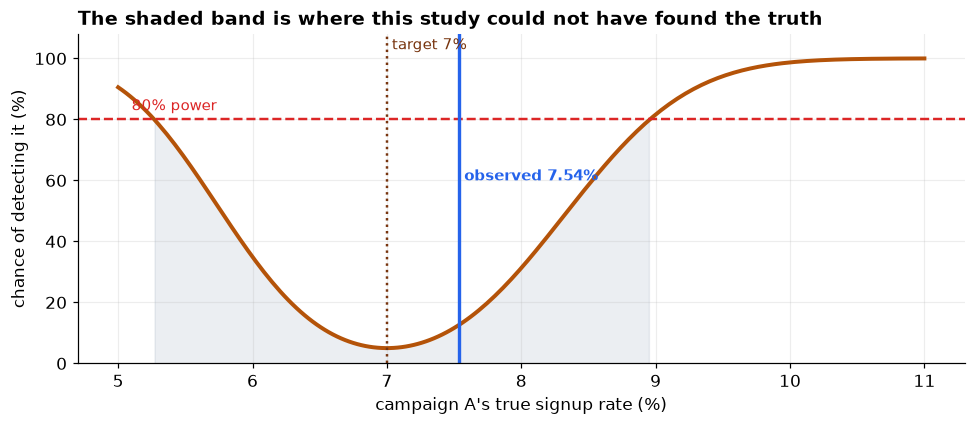

In [10]:
# The same idea drawn: what power did we have across a range of true rates?
true_rates = np.linspace(0.05, 0.11, 200)
pw = [power.solve_power(effect_size=proportion_effectsize(t, TARGET), nobs1=nA,
                        ratio=0, alpha=0.05, alternative="two-sided") if t != TARGET else 0.05
      for t in true_rates]
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.plot(true_rates*100, np.array(pw)*100, color=GOLD, lw=2.6)
ax.axhline(80, color=RD, ls="--", lw=1.6)
ax.axvline(TARGET*100, color=DARK, ls=":", lw=1.6)
ax.axvline(pA*100, color=BL, lw=2.2)
ax.fill_between(true_rates*100, 0, np.array(pw)*100, where=(np.array(pw) < 0.8), color=MUT, alpha=0.18)
ax.text(TARGET*100, 103, " target 7%", color=DARK, fontsize=9.5)
ax.text(pA*100, 60, " observed 7.54%", color=BL, fontsize=9.5, fontweight="bold")
ax.text(5.1, 83, "80% power", color=RD, fontsize=9.5)
ax.set_xlabel("campaign A's true signup rate (%)"); ax.set_ylabel("chance of detecting it (%)")
ax.set_ylim(0, 108); ax.set_title("The shaded band is where this study could not have found the truth")
plt.tight_layout(); plt.show()

**Reading the power curve.** The shaded band covers every true signup rate this study had less than an 80 percent chance of flagging, and it is wide: it swallows everything from roughly 5.0 to 9.0 percent. The observed 7.54 percent sits in the middle of it. The graph makes the limitation impossible to talk around, and it is a far more useful thing to put in a report than the sentence "the difference was not statistically significant".

## Step 9 &middot; Interpret in plain language
Campaign A is running at roughly its 7% target; this sample cannot say whether it is genuinely above or below, and reporting "A beat target" from a 7.54% observation would be overreaching. Campaign B, on the other hand, converts clearly better than A, by about **4 percentage points**, which is roughly **387 extra signups per 10,000 visitors**. If a choice has to be made between the two campaigns, the evidence supports B; if the question is whether A meets its target, the answer is that we cannot yet tell.

## Step 10 &middot; Ethics, bias, and limits
- **How were visitors assigned?** The comparison is causal only if visitors were **randomized** between campaigns. If A and B ran on different pages, days, or audiences, the difference confounds the campaign with those factors. This is the same requirement, and the same failure mode, as in [Capstone 2](../../capstone-onboarding-productivity.html).
- **Signups are not the goal.** A campaign can lift signups by promising more than the product delivers, moving the cost to churn and support later. Optimizing a single funnel metric without watching what happens downstream is how short-term wins become long-term losses.
- **Peeking inflates false positives.** Checking an experiment repeatedly and stopping when p first drops below 0.05 badly breaks the error rate. The sample size should be fixed in advance, or a sequential method used that accounts for the looking.
- **Do not read "not significant" as "no difference".** Campaign A's result is inconclusive, not negative. A larger sample could resolve which side of the target it truly sits on.

---
**From analysis to report.** The notebook carries the evidence: the cleaning, the assumption check, both tests, the exact-binomial confirmation, the intervals, and both framings of the lift. The written reports turn it into a decision a marketing lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.